In [1]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont

class TypographyFeatureExtractor:
    """
    Клас для автоматичного аналізу та вилучення топологічних та текстурних 
    характеристик із сегментованого корейського тексту манхви.
    """
    def __init__(self, korean_mask_path: str, korean_img_path: str):
        # Завантаження маски у градаціях сірого та оригінального кольорового зображення
        self.mask = cv2.imread(korean_mask_path, cv2.IMREAD_GRAYSCALE)
        self.image = cv2.imread(korean_img_path, cv2.IMREAD_COLOR)
        
        if self.mask is None or self.image is None:
            raise ValueError("Критична помилка: Неможливо завантажити вхідні зображення.")
            
        # Бінаризація маски для забезпечення чіткості меж аналізу
        _, self.binary_mask = cv2.threshold(self.mask, 127, 255, cv2.THRESH_BINARY)

    def extract_geometries(self, mode="scattered") -> list:
        """Стабільне витягування центрів, розмірів та кутів (без математичних збоїв)."""
        if mode == "single_block":
            contours, _ = cv2.findContours(self.binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            valid_contours = [c for c in contours if cv2.contourArea(c) > 50]
            if not valid_contours:
                return [{"center": (256, 256), "size": (512, 512), "angle": 0.0}]
                
            all_pts = np.vstack(valid_contours).reshape(-1, 2)
            rect = cv2.minAreaRect(all_pts)
            return [{"center": rect[0], "size": rect[1], "angle": rect[2]}]
            
        elif mode == "scattered":
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
            dilated_mask = cv2.dilate(self.binary_mask, kernel, iterations=2)
            contours, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            valid_contours = [c for c in contours if cv2.contourArea(c) > 300]
            
            if not valid_contours:
                return [{"center": (256, 256), "size": (512, 512), "angle": 0.0}]
                
            clusters = []
            for c in valid_contours:
                rect = cv2.minAreaRect(c)
                clusters.append({"center": rect[0], "size": rect[1], "angle": rect[2]})
                
            # Сортування зліва-направо або зверху-вниз
            std_x = np.std([cl["center"][0] for cl in clusters]) if len(clusters) > 1 else 1
            std_y = np.std([cl["center"][1] for cl in clusters]) if len(clusters) > 1 else 0
            if std_x > std_y: 
                clusters.sort(key=lambda x: x["center"][0])
            else: 
                clusters.sort(key=lambda x: x["center"][1])
                
            return clusters
            
        elif mode == "scattered":
            # Попередня логіка: кластеризація по літерах
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
            dilated_mask = cv2.dilate(self.binary_mask, kernel, iterations=2)
            contours, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            valid_contours = [c for c in contours if cv2.contourArea(c) > 300]
            
            if not valid_contours:
                default_corners = np.array([[0,0], [512,0], [512,512], [0,512]], dtype="float32")
                return [{"corners": default_corners, "center_x": 256, "center_y": 256}]
                
            clusters = []
            for c in valid_contours:
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                s = box.sum(axis=1)
                diff = np.diff(box, axis=1)
                corners = np.zeros((4, 2), dtype="float32")
                corners[0] = box[np.argmin(s)]
                corners[2] = box[np.argmax(s)]
                corners[1] = box[np.argmin(diff)]
                corners[3] = box[np.argmax(diff)]
                clusters.append({"corners": corners, "center_x": rect[0][0], "center_y": rect[0][1]})
                
            std_x = np.std([cl["center_x"] for cl in clusters]) if len(clusters) > 1 else 1
            std_y = np.std([cl["center_y"] for cl in clusters]) if len(clusters) > 1 else 0
            if std_x > std_y: clusters.sort(key=lambda x: x["center_x"])
            else: clusters.sort(key=lambda x: x["center_y"])
                
            return clusters

    def analyze_edge_morphology(self) -> str:
        """Визначення топології країв (гострі або заокруглені) на основі циркулярності."""
        contours, _ = cv2.findContours(self.binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return "neutral"
            
        # Вибір найбільшого контуру, який ймовірно є основним текстовим блоком
        main_contour = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(main_contour, True)
        area = cv2.contourArea(main_contour)
        
        # Математичне обчислення циркулярності (Circularity)
        circularity = 4 * np.pi * (area / (perimeter * perimeter + 1e-6))
        
        # Евристичні пороги, адаптовані для манхва-типографіки
        if circularity > 0.18:
            return "rounded"
        else:
            return "sharp"

    def detect_texture_and_gradients(self) -> dict:
        """Виявлення наявності градієнтів та складних текстур (ОНОВЛЕНО ДЛЯ КОЛЬОРУ)."""
        # Накладання маски на зображення для ізоляції тексту від фону
        masked_img = cv2.bitwise_and(self.image, self.image, mask=self.binary_mask)
        
        # 1. ПЕРЕВЕДЕННЯ В HSV ДЛЯ АНАЛІЗУ КОЛЬОРУ
        hsv_masked = cv2.cvtColor(masked_img, cv2.COLOR_BGR2HSV)
        h_channel, s_channel, v_channel = cv2.split(hsv_masked)
        
        # Обчислення дисперсії для Відтінку (Hue) та Яскравості (Value)
        _, stddev_h = cv2.meanStdDev(h_channel, mask=self.binary_mask)
        _, stddev_v = cv2.meanStdDev(v_channel, mask=self.binary_mask)
        
        # Беремо найбільше відхилення: текст може змінювати або колір, або яскравість
        color_variance = max(float(stddev_h[0][0]), float(stddev_v[0][0]))
        
        # 2. АНАЛІЗ ТЕКСТУРИ (Залишаємо в сірому для виявлення зернистості)
        gray_masked = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
        laplacian_variance = cv2.Laplacian(gray_masked, cv2.CV_64F).var()
        
        # 3. ЗНИЖЕНІ ПОРОГИ ЧУТЛИВОСТІ
        has_gradient = color_variance > 8.0 # Було 15.0, тепер ловить м'якші градієнти
        has_texture = laplacian_variance > 300.0 # Було 500.0
        
        return {
            "has_gradient": has_gradient, 
            "has_texture": has_texture,
            "color_variance": color_variance,
            "texture_complexity": laplacian_variance
        }

In [2]:
def render_and_warp_cyrillic_text(geometry_params: dict, canvas_size: tuple = (512, 512)) -> np.ndarray:
    """
    Рендеринг слова 'Тест' та його анізотропна деформація (розтягування/стиснення) 
    для відтворення просторових пропорцій корейського оригіналу.
    """
    # Створення чорного базового полотна
    base_image = Image.new("L", canvas_size, color=0)
    draw_context = ImageDraw.Draw(base_image)
    
    # Використання максимально масивного шрифту як базової структури для коміксів
    try:
        font = ImageFont.truetype("Grinched.ttf", 150)
    except IOError:
        font = ImageFont.load_default()
        
    target_text = "Тест"
    
    # Визначення фізичних розмірів відрендереного тексту
    bounding_box = draw_context.textbbox((0, 0), target_text, font=font)
    text_width = bounding_box - bounding_box
    text_height = bounding_box - bounding_box
    
    # Центрування тексту на полотні
    center_x = (canvas_size - text_width) // 2
    center_y = (canvas_size - text_height) // 2
    draw_context.text((center_x, center_y), target_text, fill=255, font=font)
    
    rendered_array = np.array(base_image)
    
    # Отримання цільового та поточного співвідношення сторін
    target_aspect_ratio = geometry_params["aspect_ratio"]
    current_aspect_ratio = text_width / float(text_height)
    
    # Обчислення нових розмірів для анізотропної деформації
    if current_aspect_ratio > target_aspect_ratio:
        # Українське слово занадто широке -> горизонтальне стиснення
        warped_width = int(text_width * (target_aspect_ratio / current_aspect_ratio))
        warped_height = text_height
    else:
        # Українське слово занадто вузьке -> горизонтальне розтягування
        warped_width = text_width
        warped_height = int(text_height * (current_aspect_ratio / target_aspect_ratio))
        
    # Кадрування тексту для усунення зайвого фону перед деформацією
    rx, ry, rw, rh = cv2.boundingRect(rendered_array)
    cropped_cyrillic = rendered_array[ry:ry+rh, rx:rx+rw]
    
    # Афінне масштабування з кубічною інтерполяцією для запобігання втраті піксельної щільності
    warped_text = cv2.resize(cropped_cyrillic, (warped_width, warped_height), interpolation=cv2.INTER_CUBIC)
    
    # Формування нового полотна з деформованим текстом
    final_canvas = np.zeros(canvas_size, dtype=np.uint8)
    start_x = (canvas_size - warped_width) // 2
    start_y = (canvas_size - warped_height) // 2
    
    final_canvas[start_y:start_y+warped_height, start_x:start_x+warped_width] = warped_text
    
    # Жорстка бінаризація після інтерполяції для отримання ідеально гострих країв
    _, binary_warped_mask = cv2.threshold(final_canvas, 127, 255, cv2.THRESH_BINARY)
    
    return binary_warped_mask

In [3]:
def apply_morphological_edge_adaptation(warped_mask: np.ndarray, edge_style: str) -> np.ndarray:
    """
    Модифікація мікроструктури країв маски тексту для досягнення
    ефекту заокруглення або агресивного загострення за допомогою OpenCV.
    """
    adapted_mask = warped_mask.copy()
    
    if edge_style == "rounded":
        # Застосування інтенсивного розмиття Гауса для пом'якшення всіх кутів.
        # Розмір ядра (25, 25) гарантує значне перекриття просторових частот.
        blurred_mask = cv2.GaussianBlur(adapted_mask, (25, 25), 0)
        
        # Застосування жорсткого порогу відновлює різкість межі, 
        # конвертуючи розмиті кути у математично правильні дуги.
        _, adapted_mask = cv2.threshold(blurred_mask, 127, 255, cv2.THRESH_BINARY)
        
    elif edge_style == "sharp":
        # Створення морфологічних структурних елементів з гострими контурами
        rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (9, 9))
        
        # Хрестоподібна дилатація виштовхує пікселі назовні по діагоналях та осях,
        # створюючи візуальні "шипи" на кутах літер.
        dilated_mask = cv2.dilate(adapted_mask, cross_kernel, iterations=2)
        
        # Ерозія прямокутним ядром частково повертає товщину літер до норми, 
        # залишаючи при цьому згенеровані гострі виступи на краях.
        adapted_mask = cv2.erode(dilated_mask, rect_kernel, iterations=1)
        
    return adapted_mask

In [4]:
def get_clean_style_reference(image, mask):
    # Знаходимо межі тексту
    x, y, w, h = cv2.boundingRect(mask)
    crop_img = image[y:y+h, x:x+w]
    crop_mask = mask[y:y+h, x:x+w]
    
    # Створюємо фон, заповнений середнім кольором тексту (щоб не було контрасту з білим)
    mean_color = cv2.mean(crop_img, mask=crop_mask)[:3]
    background = np.full_like(crop_img, mean_color, dtype=np.uint8)
    
    # Накладаємо текст на цей нейтральний фон
    res = cv2.bitwise_and(crop_img, crop_img, mask=crop_mask)
    inv_mask = cv2.bitwise_not(crop_mask)
    bg_part = cv2.bitwise_and(background, background, mask=inv_mask)
    
    combined = cv2.add(res, bg_part)
    return cv2.resize(combined, (512, 512), interpolation=cv2.INTER_AREA)

In [5]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel
from diffusers import EulerAncestralDiscreteScheduler

def generate_texture_zero_shot(
    ukr_adapted_mask: np.ndarray, 
    korean_style_image_path: str, 
    korean_mask_path: str,
    texture_params: dict
) -> np.ndarray:
    
    # 1. Підготовка просторових умов (Canny Edge Map)
    mask_uint8 = ukr_adapted_mask.astype(np.uint8)
    edges_map = cv2.Canny(mask_uint8, 100, 200)
    edges_3c = cv2.cvtColor(edges_map, cv2.COLOR_GRAY2RGB)
    controlnet_cond_image = Image.fromarray(edges_3c)
    
    # ---------------------------------------------------------
    # НОВЕ: Ідеальна обрізка стилю за допомогою оригінальної маски
    # Це ігнорує будь-який фон (білий, чорний чи малюнок)
    # ---------------------------------------------------------
    style_cv = cv2.imread(korean_style_image_path)
    style_cv = cv2.cvtColor(style_cv, cv2.COLOR_BGR2RGB)
    
    kor_mask = cv2.imread(korean_mask_path, cv2.IMREAD_GRAYSCALE)
    _, kor_mask_bin = cv2.threshold(kor_mask, 127, 255, cv2.THRESH_BINARY)
    
    if style_cv.shape[:2] == kor_mask_bin.shape[:2]:
        rx, ry, rw, rh = cv2.boundingRect(kor_mask_bin)
        if rw > 0 and rh > 0:
            crop_style = style_cv[ry:ry+rh, rx:rx+rw]
            crop_mask = kor_mask_bin[ry:ry+rh, rx:rx+rw]
            
            # Телеа-Інпейнтінг: продовжуємо кольори тексту на пустий фон
            bg_mask = cv2.bitwise_not(crop_mask)
            inpainted_style = cv2.inpaint(crop_style, bg_mask, 3, cv2.INPAINT_TELEA)
            
            style_cv = cv2.resize(inpainted_style, (512, 512), interpolation=cv2.INTER_CUBIC)
            
    reference_style_image = Image.fromarray(style_cv)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # ---------------------------------------------------------
    # АРХІТЕКТУРА STABLE DIFFUSION 1.5 (ОПТИМІЗОВАНО ДЛЯ 8-12 ГБ)
    # ---------------------------------------------------------
    from diffusers import StableDiffusionControlNetPipeline # Важливо! Звичайний пайплайн, не XL
    
    # Завантаження ControlNet для SD 1.5
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny", 
        torch_dtype=torch.float16
    ).to(device)
    
    # Ініціалізація базового пайплайну SD 1.5
    pipeline = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16,
        use_safetensors=True, 
        safety_checker=None,
        feature_extractor=None
    )
    
    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config)
    
    # 1. СПОЧАТКУ завантажуємо IP-Adapter у пайплайн
    pipeline.load_ip_adapter(
        "h94/IP-Adapter", 
        subfolder="models",                           
        weight_name="ip-adapter-plus_sd15.safetensors" 
    )
    pipeline.set_ip_adapter_scale(0.85)
    
    # 2. І ТІЛЬКИ ПОТІМ вмикаємо розвантаження пам'яті (щоб воно охопило і IP-Adapter)
    pipeline.enable_model_cpu_offload() 
    pipeline.enable_vae_slicing()
    pipeline.enable_vae_tiling()
    
    # 4. Динамічні промпти
    base_prompt = "highly detailed typography, manga comic text effect, stylized font, manhwa lettering style, perfect rendering"
    negative_prompt = "distorted letters, bad anatomy, messy, artifacts, watermark, low resolution, standard font, background noise"
    
    if not texture_params["has_gradient"]:
        base_prompt += ", flat color, solid fill, monochrome design, no gradient"
        negative_prompt += ", gradient, 3d render, shadows, highlights"
    
    if texture_params["has_texture"]:
        base_prompt += ", rich texture, halftone dots, comic screentones, distressed surface"
    else:
        base_prompt += ", clean surface, smooth vector art"
        
    # 5. Генерація
    generated_images = pipeline(
        prompt=base_prompt,
        negative_prompt=negative_prompt,
        image=controlnet_cond_image,            
        ip_adapter_image=reference_style_image, 
        num_inference_steps=30,
        guidance_scale=7.5,
        controlnet_conditioning_scale=1.0
    ).images
    
    return np.array(generated_images[0])

c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def final_image_compositing(stylized_rgb_image: np.ndarray, ukr_adapted_mask: np.ndarray) -> np.ndarray:
    """
    Застосування структурної маски як альфа-каналу для забезпечення абсолютно 
    прозорого фону та відсікання генеративних артефактів навколо стилізованого тексту.
    """
    # Гарантування математичного збігу просторових розмірностей матриць
    height, width = ukr_adapted_mask.shape
    if stylized_rgb_image.shape[:2]!= (height, width):
        # Якщо дифузійна модель повернула інший розмір, примусове лінійне масштабування
        stylized_rgb_image = cv2.resize(stylized_rgb_image, (width, height), interpolation=cv2.INTER_LINEAR)
        
    # Розділення кольорових каналів зображення (SDXL повертає RGB, OpenCV використовує BGR)
    # Зображення конвертується у BGR для коректної роботи з OpenCV
    stylized_bgr_image = cv2.cvtColor(stylized_rgb_image, cv2.COLOR_RGB2BGR)
    blue_channel, green_channel, red_channel = cv2.split(stylized_bgr_image)
    
    # Використання бінарної маски як матриці альфа-каналу (прозорості).
    # Застосування незначного розмиття Гауса для забезпечення anti-aliasing країв.
    alpha_channel = cv2.GaussianBlur(ukr_adapted_mask, (3, 3), 0)
    
    # Злиття каналів для формування фінального 4-канального зображення (BGRA)
    final_rgba_image = cv2.merge((blue_channel, green_channel, red_channel, alpha_channel))
    
    return final_rgba_image

In [7]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# 1. Оновлена функція рендеру, яка приймає бажаний текст як аргумент
def split_text_into_chunks(text: str, num_chunks: int) -> list:
    """Розбиває український текст на групи літер відповідно до кількості корейських символів."""
    n = len(text)
    if num_chunks >= n:
        return list(text) + [""] * (num_chunks - n)
        
    chunk_size = max(1, n // num_chunks)
    chunks = []
    for i in range(num_chunks):
        if i == num_chunks - 1:
            chunks.append(text[i*chunk_size:]) # Останній кластер забирає всі залишки
        else:
            chunks.append(text[i*chunk_size:(i+1)*chunk_size])
    return chunks

def render_and_warp_cyrillic_text_dynamic(target_text: str, clusters: list, canvas_size: tuple = (512, 512)) -> np.ndarray:
    text_chunks = split_text_into_chunks(target_text, len(clusters))
    
    try:
        # Шлях до вашого шрифту (має бути в папці з проєктом)
        font_path = "Grinched.ttf" 
        font = ImageFont.truetype(font_path, 150)
    except IOError:
        print(f"Шрифт {font_path} не знайдено, використовується arialbd.ttf")
        font = ImageFont.truetype("arialbd.ttf", 150)
        
    centers = np.array([cl["center"] for cl in clusters])
    center_of_all = (np.min(centers, axis=0) + np.max(centers, axis=0)) / 2
    
    # Використовуємо велике тимчасове полотно для збірки
    temp_canvas = np.zeros((2048, 2048), dtype=np.uint8) 
    
    for chunk_text, cluster in zip(text_chunks, clusters):
        if not chunk_text: continue
            
        # 1. Рендеримо текст на маленькому полотні
        base_image = Image.new("L", (800, 400), color=0)
        draw = ImageDraw.Draw(base_image)
        bbox = draw.textbbox((0, 0), chunk_text, font=font)
        
        # ВИПРАВЛЕНО: Правильний розрахунок розмірів
        tw = bbox[2] - bbox[0]
        th = bbox[3] - bbox[1]
        
        # Малюємо по центру локального полотна
        draw.text((400 - tw//2 - bbox[0], 200 - th//2 - bbox[1]), chunk_text, fill=255, font=font)
        
        rendered = np.array(base_image)
        rx, ry, rw, rh = cv2.boundingRect(rendered)
        cropped_chunk = rendered[ry:ry+rh, rx:rx+rw]
        
        # 2. Геометрія кластера
        cw, ch = cluster["size"]
        angle = cluster["angle"]
        
        # ВИПРАВЛЕНО: Логіка нормалізації кута OpenCV
        # Текст має йти вздовж довшої сторони
        if cw < ch:
            cw, ch = ch, cw
            angle -= 90  # Або -= 90, залежно від орієнтації
            
        # 3. Деформація (Warping)
        warped_chunk = cv2.resize(cropped_chunk, (int(cw), int(ch)), interpolation=cv2.INTER_CUBIC)
        
        # 4. Обертання
        # Робимо паддінг, щоб кути не обрізалися при повороті
        pad = max(int(cw), int(ch)) * 2
        padded = np.zeros((pad, pad), dtype=np.uint8)
        px, py = (pad - int(cw))//2, (pad - int(ch))//2
        padded[py:py+int(ch), px:px+int(cw)] = warped_chunk
        
        M = cv2.getRotationMatrix2D((pad//2, pad//2), angle, 1.0)
        rotated = cv2.warpAffine(padded, M, (pad, pad), flags=cv2.INTER_CUBIC)
        
        # Обрізаємо лишній чорний фон після повороту
        rrx, rry, rrw, rrh = cv2.boundingRect(rotated)
        if rrw <= 0 or rrh <= 0: continue
        final_rot = rotated[rry:rry+rrh, rrx:rrx+rrw]
        
        # 5. Розміщення на великому полотні
        cx, cy = cluster["center"]
        # Зміщення відносно центру всієї фрази
        off_x, off_y = cx - center_of_all[0], cy - center_of_all[1]
        
        # Центр полотна 2048x2048 - це 1024
        start_x = int(1024 + off_x - rrw//2)
        start_y = int(1024 + off_y - rrh//2)
        
        # Перевірка меж перед копіюванням
        if start_x >= 0 and start_y >= 0:
            roi = temp_canvas[start_y:start_y+rrh, start_x:start_x+rrw]
            temp_canvas[start_y:start_y+rrh, start_x:start_x+rrw] = np.maximum(roi, final_rot)
        
    # 6. Фінальне кадрування та вписування у 512x512
    fx, fy, fw, fh = cv2.boundingRect(temp_canvas)
    if fw > 0 and fh > 0:
        final_crop = temp_canvas[fy:fy+fh, fx:fx+fw]
        # Масштабуємо, щоб текст займав ~90% полотна
        scale = min(460 / fw, 460 / fh)
        final_resized = cv2.resize(final_crop, (0,0), fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
        
        h, w = final_resized.shape
        res_canvas = np.zeros(canvas_size, dtype=np.uint8)
        sx, sy = (512 - w)//2, (512 - h)//2
        res_canvas[sy:sy+h, sx:sx+w] = final_resized
        
        _, bin_mask = cv2.threshold(res_canvas, 127, 255, cv2.THRESH_BINARY)
        return bin_mask
        
    return np.zeros(canvas_size, dtype=np.uint8)

1. Аналіз оригіналу (Режим: scattered)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


c:\UnProg\DIPLOMA\venv_diploma\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 4260.47it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  4.32it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNe


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


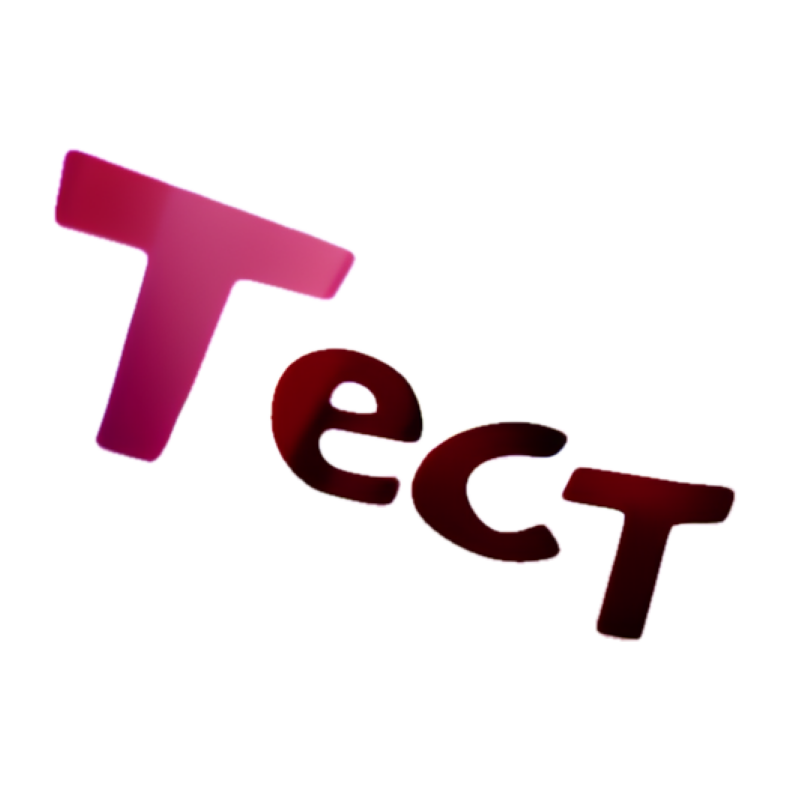

In [8]:
# ==========================================
# ГОЛОВНИЙ БЛОК ВИКОНАННЯ (MAIN)
# ==========================================

# 2. Налаштування вхідних даних
KOREAN_MASK_PATH = "inpaint_mask5.png"   
KOREAN_IMG_PATH = "imgs/5.jpg"     
KOREAN_STYLE_PATH = KOREAN_IMG_PATH                   
TARGET_UKR_TEXT = "Тест" 

# Виберіть режим: 
# "single_block" (для помахів меча, цільних звуків) 
# "scattered" (для розкиданих окремих літер)
TEXT_MODE = "scattered"  

OUTPUT_IMAGE_PATH = "stylized_ukr_result.png"

def run_typography_pipeline():
    print(f"1. Аналіз оригіналу (Режим: {TEXT_MODE})...")
    extractor = TypographyFeatureExtractor(KOREAN_MASK_PATH, KOREAN_IMG_PATH)
    
    geo_params = extractor.extract_geometries(mode=TEXT_MODE) # Вказуємо режим!
    edge_style = extractor.analyze_edge_morphology()
    tex_params = extractor.detect_texture_and_gradients()
    
    print("\n2. Генерація та деформація українського тексту...")
    base_mask = render_and_warp_cyrillic_text_dynamic(TARGET_UKR_TEXT, geo_params)

    print("\n3. Адаптація морфології країв...")
    adapted_mask = apply_morphological_edge_adaptation(base_mask, edge_style)

    print("\n4. Перенесення стилю...")
    # Передаємо KOREAN_MASK_PATH у функцію!
    stylized_rgb = generate_texture_zero_shot(adapted_mask, KOREAN_STYLE_PATH, KOREAN_MASK_PATH, tex_params)

    print("\n5. Фінальне композитування...")
    final_rgba = final_image_compositing(stylized_rgb, adapted_mask)

    cv2.imwrite(OUTPUT_IMAGE_PATH, final_rgba)
    print(f"Готово! Збережено як: {OUTPUT_IMAGE_PATH}")

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(final_rgba, cv2.COLOR_BGRA2RGBA))
    plt.axis('off')
    plt.show()

run_typography_pipeline()

In [9]:
def multy_plot(i: int, mode_cs: str):
    # 2. Налаштування вхідних даних
    KOREAN_MASK_PATH = f"inpaint_mask{i}.png"   
    KOREAN_IMG_PATH = f"imgs/{i}.jpg"     
    KOREAN_STYLE_PATH = KOREAN_IMG_PATH                   
    TARGET_UKR_TEXT = "Тест" 

    # Виберіть режим: 
    # "single_block" (для помахів меча, цільних звуків) 
    # "scattered" (для розкиданих окремих літер)
    TEXT_MODE = mode_cs  

    OUTPUT_IMAGE_PATH = "stylized_ukr_result.png"

    def run_typography_pipeline():
        print(f"1. Аналіз оригіналу (Режим: {TEXT_MODE})...")
        extractor = TypographyFeatureExtractor(KOREAN_MASK_PATH, KOREAN_IMG_PATH)
        
        geo_params = extractor.extract_geometries(mode=TEXT_MODE) # Вказуємо режим!
        edge_style = extractor.analyze_edge_morphology()
        tex_params = extractor.detect_texture_and_gradients()
        
        print("\n2. Генерація та деформація українського тексту...")
        base_mask = render_and_warp_cyrillic_text_dynamic(TARGET_UKR_TEXT, geo_params)

        print("\n3. Адаптація морфології країв...")
        adapted_mask = apply_morphological_edge_adaptation(base_mask, edge_style)

        print("\n4. Перенесення стилю...")
        # Передаємо KOREAN_MASK_PATH у функцію!
        stylized_rgb = generate_texture_zero_shot(adapted_mask, KOREAN_STYLE_PATH, KOREAN_MASK_PATH, tex_params)

        print("\n5. Фінальне композитування...")
        final_rgba = final_image_compositing(stylized_rgb, adapted_mask)

        cv2.imwrite(OUTPUT_IMAGE_PATH, final_rgba)
        print(f"Готово! Збережено як: {OUTPUT_IMAGE_PATH}")
        
        fig, ax = plt.subplots(2, figsize=(10, 10))

        ax[0].imshow(cv2.cvtColor(final_rgba, cv2.COLOR_BGRA2RGBA))
        ax[0].set_axis_off()
        
        org_img = cv2.imread(KOREAN_IMG_PATH)
        org_img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)
        ax[1].imshow(org_img)
        ax[1].set_title("Korean Text")
        ax[1].set_axis_off()

    run_typography_pipeline()

1. Аналіз оригіналу (Режим: scattered)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2522.72it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  2.55it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep 


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


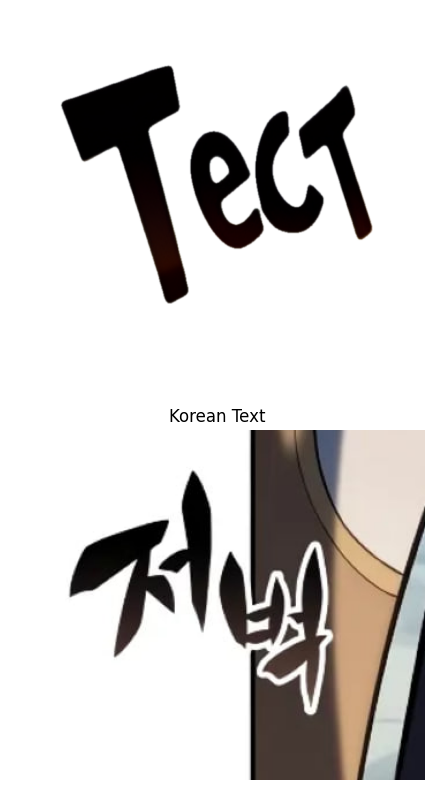

In [10]:
multy_plot(4, "scattered")

1. Аналіз оригіналу (Режим: scattered)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3493.16it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  3.31it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep 


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


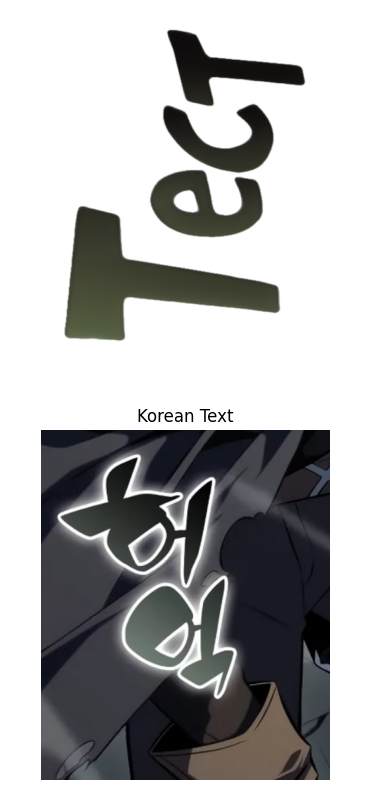

In [11]:
multy_plot(3, "scattered")

1. Аналіз оригіналу (Режим: single_block)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2226.46it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:02<00:00,  2.27it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep 


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


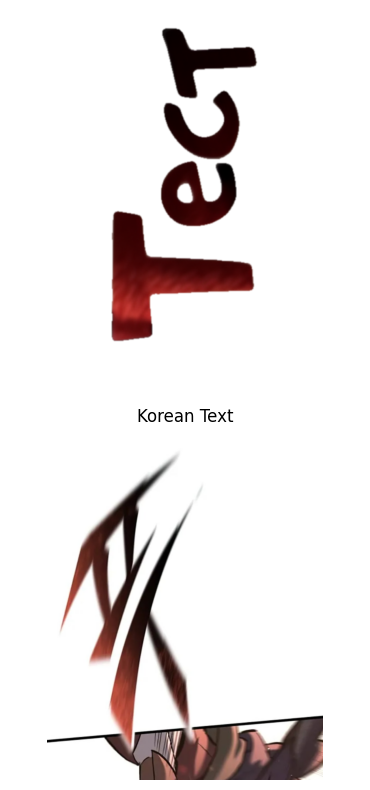

In [12]:
multy_plot(2, "single_block")

1. Аналіз оригіналу (Режим: scattered)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2010.00it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:04<00:00,  1.07it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep 


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


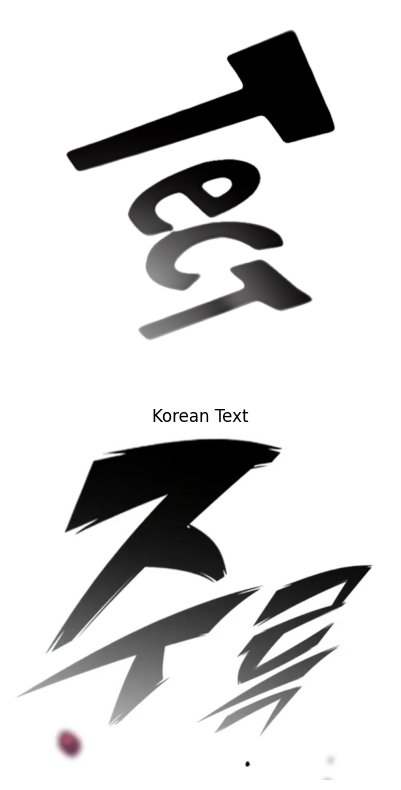

In [13]:
multy_plot(1, "scattered")

1. Аналіз оригіналу (Режим: scattered)...

2. Генерація та деформація українського тексту...

3. Адаптація морфології країв...

4. Перенесення стилю...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2015.88it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\berku\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 5/5 [00:01<00:00,  3.36it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep 


5. Фінальне композитування...
Готово! Збережено як: stylized_ukr_result.png


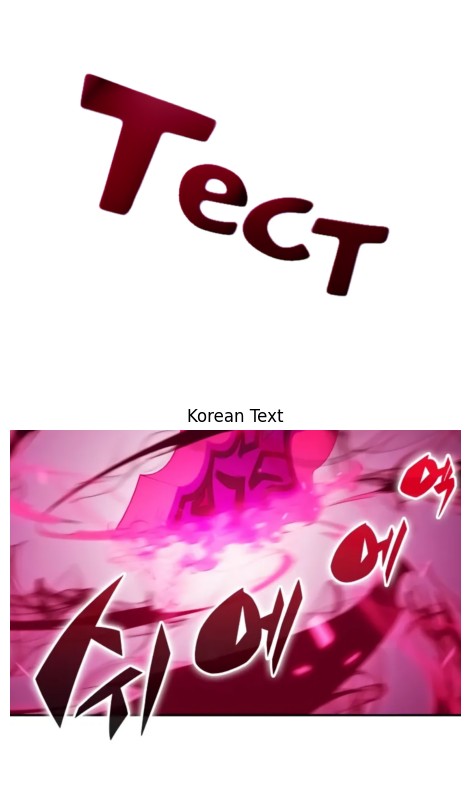

In [14]:
multy_plot(5, "scattered")